In [1]:
using Catalyst: spatial_convert_err
include("../src/DiscreteStochasticSimulation.jl")
#include("../src/core/ssa.jl")
using .DiscreteStochasticSimulation
using Catalyst
using ProgressMeter 
ProgressMeter.ijulia_behavior(:clear)
using Plots
using Expokit
using SparseArrays

using DifferentialEquations 
using OrdinaryDiffEq
using JLD

┌ Warning: Replacing docs for `Main.DiscreteStochasticSimulation.FindLowestValuesPercent :: Union{Tuple{T}, Tuple{Vector{T}, Number}} where T` in module `Main.DiscreteStochasticSimulation`
└ @ Base.Docs docs/Docs.jl:243


In [2]:
# Create model.
rn = @reaction_network begin
    (η*(α₁ + (β₁*K₁^3/(K₁^3 + V^3))), d₁+s*γ/(1+s)), 0 <--> U 
    (η*(α₂ + (β₂*K₂^3/(K₂^3 + U^3))), d₂), 0 <--> V
end

Model ##ReactionSystem#236
Unknowns (2):
  U(t)
  V(t)
Parameters (11):
  η
  α₁
  β₁
  K₁
  d₁
  s
⋮

In [3]:
model = DiscreteStochasticSystem(rn);
display.(jumpratelaw.(Catalyst.get_rxs(rn)));

(((K₁^3)*β₁) / (K₁^3 + V(t)^3) + α₁)*η

(d₁ + (s*γ) / (1 + s))*U(t)

(((K₂^3)*β₂) / (K₂^3 + U(t)^3) + α₂)*η

d₂*V(t)

In [4]:
 # define boundaries (rectangular lattice in this case)
bounds = (0, 600) #(lower limit, upper limit)
boundary_condition(x) = RectLatticeBoundaryCondition(x, bounds);

In [5]:
# define initial value and expand the space a bit 
U₀ = CartesianIndex(85, 5)

#time
δt = 0.5
T = 0:δt:50

0.0:0.5:50.0

In [6]:
# define initial value and expand the space a bit 
U₀ = CartesianIndex(85, 5)

#time
δt = 0.5
T = 0:δt:50

# definine initial state set 
scale=100
rates = [1.0, 0.2*scale, 4.0*scale, 1.0*scale, 1.0, 0.1, 1.0, 0.2*scale, 4.0*scale, 1.0*scale, 1.0]
X = Set([U₀])
X = Expand!(X, model, rates, 0.0, boundary_condition, 2);

# initial probability vector (only for active states)
p₀ = zeros(X |> length)
p₀[DiscreteStochasticSimulation.FindElement(U₀, X)] = 1


global iter = 1
global pₜ = p₀
global sz = []
global sm
global m =[]

# time intrerval 
sol = Array{SparseMatrixCSC,1}(undef, length(T))
global p = Progress(length(T))

joint_plot = plot()
for t ∈ T
    
    #expand space and assemble matrix
    global X, pₜ = Expand!(X, pₜ, model, rates, t, boundary_condition, 50);
    push!(sz, length(X))
    global A = MasterEquation(X, model, rates, boundary_condition, t)
    
    # solve system and normalize (using expokit (can also use numerical time steppers such as Runge-Kutta))
    pₜ = expmv(δt, A, pₜ)
    sm =sum(A) 

    # add add states in sparse arrays 
    I = [a[1] for a in X] 
    J = [a[2] for a in X] 
    sol[iter] = sparse(I, J, pₜ)
    
    # purge lowest 80% probability states (most will be zero; this is arbitrary as of now)
    X, pₜ = Purge!(X, pₜ, 1e-8)
    push!(m, 1.0 - sum(pₜ) + sum(abs.(pₜ .- (pₜ ./ sum(pₜ)))))
    pₜ ./= sum(pₜ) # re-normalize the reduced state space
  
    # sparse matrix 
    global iter+=1

    # comment following line if not using progress meter
    next!(p; showvalues = [
                          ("time (t)", t),
                          ("system size",sz[end]), 
                           ("sum",sm),
                           (" ", " "), 
                           ("system size (after purge)",length(pₜ)),
                          ("num pruned states", sz[end]-length(pₜ)),
                          ("pruned mass", m[end])])

    t = t + δt
end
#@save "sol_10_29.jld" sol

Progress: 100%|█████████████████████████████████████████| Time: 0:15:50
  time (t):                   50.0
  system size:                23891
  sum:                        -5.0590642786119133e-11
   :                           
  system size (after purge):  15651
  num pruned states:          8240
  pruned mass:                3.6546162951572848e-19


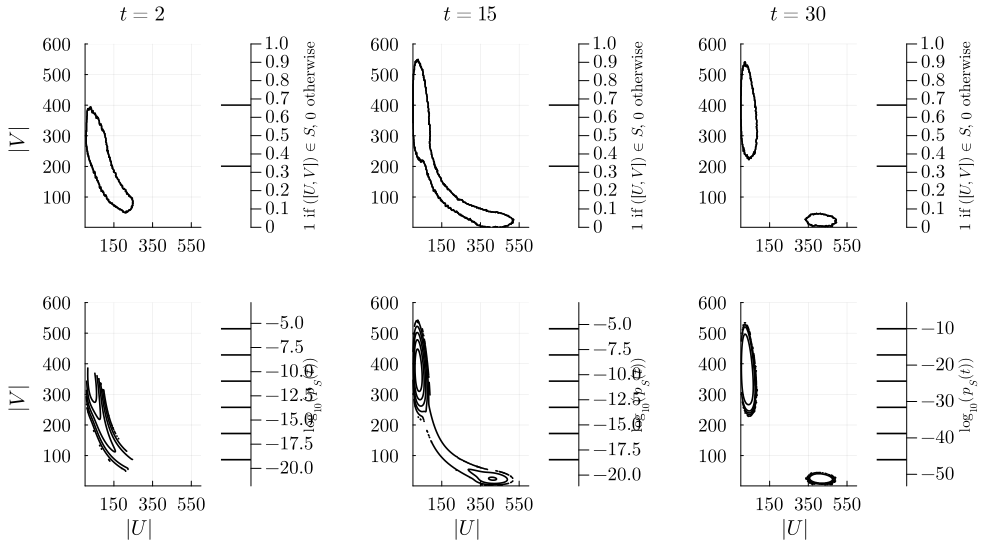

"/home/adiden/DiscreteStochasticSimulation/examples/toggle_switch_grid.pdf"

In [15]:
using Plots
using LaTeXStrings

# Initialize plot array
plots = []

# Iterate over selected solution indices
for idx in [10, 28, length(sol)-11]
    P = zeros(600, 600)
    I, J, V = findnz(sol[idx])
    states = [CartesianIndex(x...) for x ∈ eachrow(hcat(I, J))]

    # Active states contour (binary)
    P .= 0
    P[states] .= 1
    push!(plots, Plots.plot(Plots.contour(P, color=:black, fill=false, linewidth=1.5, levels=2, colorbar_title = L"1 if $([U, V]) \in S$, $0$ otherwise", colorbar_ticks=[0, 1])))

    # Log intensity contour
    P .= 0
    P[states] .= V
    push!(plots, Plots.plot(Plots.contour(log10.(abs.(P)), color=:black, fill=false, linewidth=1.65, levels=6, colorbar_title = L"\operatorname{log}_{10}(p_S(t))")))
end

# Arrange plots in a 2x3 grid
plots = [plots...]
plots=[plots[1], plots[3], plots[5], plots[2], plots[4], plots[6]]

# lables and titles
Plots.title!(plots[1], L"t = 2")
Plots.title!(plots[2], L"t = 15")
Plots.title!(plots[3], L"t = 30")

#xlaberl
Plots.xlabel!(plots[4], L"|U|")
Plots.xlabel!(plots[5], L"|U|")
Plots.xlabel!(plots[6], L"|U|")

Plots.ylabel!(plots[1], L"|V|")
Plots.ylabel!(plots[4], L"|V|")

p = Plots.plot(plots..., layout=grid(2, 3), size=(1000,550), margin=5Plots.mm, xticks=[150, 350, 550], subtitle = "My Subtitle")
display(p)

 21.736326 seconds (556.70 M allocations: 20.670 GiB, 29.74% gc time, 3.48% compilation time: <1% of which was recompilation)


[ Info: Saved animation to /home/adiden/DiscreteStochasticSimulation/examples/anim_fps15.gif


Plots.AnimatedGif("/home/adiden/DiscreteStochasticSimulation/examples/anim_fps15.gif")
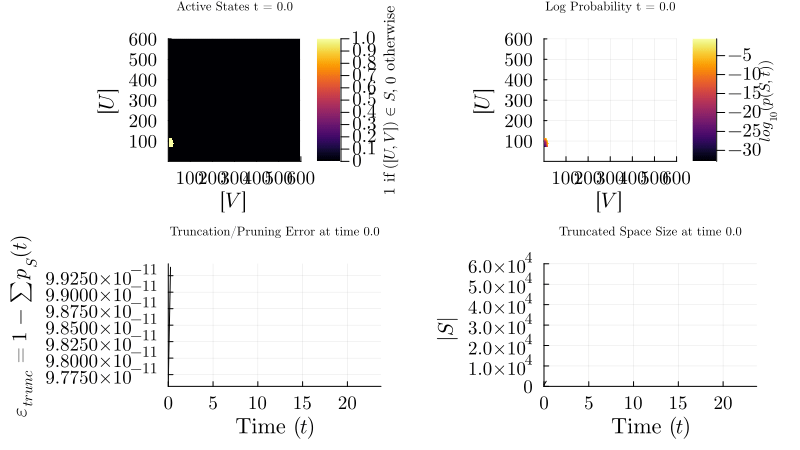

In [68]:
time_length=length(T)-25
@time begin
    P = zeros(600, 600)
    a = @animate for i ∈ 1:time_length

        #extract active states
        I, J, V = findnz(sol[i])
        states = [CartesianIndex(x...) for x ∈ eachrow(hcat(I, J))]

        # heatmap showing active states
        P .= 0
        P[states] .= 1
        h = Plots.heatmap(P, colorbar_title = L"1 if $([U, V]) \in S$, $0$ otherwise", colorbar_ticks=[0, 1])

        # heatmap for proa
        P .= 0
        P[states] .= V
        s = Plots.heatmap(log10.(abs.(P)), colorbar_title = L"log_{10}(p(S, t))")

        # bottom left plot
        p1 = Plots.plot(T[1:i+1], m[1:i+1];legend=false, color=:black)
        Plots.xlims!(p1, (0, T[time_length]))

        # bottom left plot
        p2 = Plots.plot(T[1:i+1], sz[1:i+1];legend=false, color=:black)
        Plots.xlims!(p2, (0, T[time_length]))
        Plots.ylims!(p2, (0, 6e4))
 
        # title for each polot
        Plots.title!(h, "Active States t = $(T[i])", titlefontsize=8)
        Plots.title!(s, "Log Probability t = $(T[i])", titlefontsize=8)
        Plots.title!(p1, "Truncation/Pruning Error at time $(T[i])", titlefontsize=8)
        Plots.title!(p2, "Truncated Space Size at time $(T[i])", titlefontsize=8)

        #xlabel
        Plots.xlabel!(h, L"[V]", fontsize=8)
        Plots.xlabel!(s, L"[V]", fontsize=8)
        Plots.xlabel!(p1, L"Time ($t$)", fontsize=8)
        Plots.xlabel!(p2, L"Time ($t$)", fontsize=8)

        #ylabel
        Plots.ylabel!(h, L"[U]", fontsize=8)
        Plots.ylabel!(s, L"[U]", fontsize=8)
        Plots.ylabel!(p1, L"\epsilon_{trunc} = 1 - \sum p_S(t)", fontsize=8)
        Plots.ylabel!(p2, L"|S|", fontsize=8)

        
        Plots.plot(h, s, p1, p2, layout=grid(2, 2), size=(800,450), margin=5Plots.mm)
    end  
end 
gif(a, "anim_fps15.gif")